# CSE475 — Task 1: Exploratory Data Analysis (UNSW-NB15)

**Group NN · Track 1 (GNN on table-style data) · Summer 2026**

Dataset: [UNSW-NB15](https://research.unsw.edu.au/projects/unsw-nb15-dataset) — network intrusion detection.

This notebook covers the required EDA items **A–H**:

| Item | Content |
|---|---|
| A | Summary table (name, source, samples, classes, features, hosts, balance, missing, duplicates) |
| B | Statistics (mean, median, std, min/max, quartiles, skewness, kurtosis, outliers) |
| C | Data quality (missing %, duplicates, near-constant / highly-correlated features, outliers) |
| D | Class balance (counts, bar chart, effect on metrics) |
| E | Feature distributions (histograms, boxplots, violin plots) |
| F | Correlation (heatmap, redundant-feature list) |
| G | 2D/3D view with PCA / t-SNE / UMAP |
| H | Interactive plots (Plotly) |

---

In [1]:
import os
import subprocess
import sys
import warnings

warnings.filterwarnings("ignore")

# --- Environment detection: local / Google Colab / Kaggle ---------------------
IN_COLAB = "google.colab" in sys.modules
IN_KAGGLE = bool(os.environ.get("KAGGLE_KERNEL_RUN_TYPE")) or os.path.isdir("/kaggle/input")
ENV = "Colab" if IN_COLAB else ("Kaggle" if IN_KAGGLE else "local")
print(f"environment: {ENV}")

# Colab and Kaggle both ship pandas/numpy/matplotlib/seaborn/scipy/sklearn/plotly.
# umap-learn is the only one that may be missing (Colab lacks it); install on demand.
# Local run: pip install pandas numpy matplotlib seaborn scikit-learn plotly umap-learn scipy
try:
    import umap  # noqa: F401
except ImportError:
    if IN_COLAB or IN_KAGGLE:
        print("installing umap-learn ...")
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", "umap-learn"], check=False
        )

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 60)

# Plotly needs an explicit renderer on Colab; Kaggle and local Jupyter autodetect.
if IN_COLAB:
    import plotly.io as pio
    pio.renderers.default = "colab"

RANDOM_STATE = 42

environment: Kaggle


## 0 · Load the data

In [2]:
def _all_csvs(root: Path, max_depth: int = 4):
    """CSV files under `root`, searched breadth-first up to `max_depth` levels."""
    if not root.exists():
        return []
    found = []
    for depth in range(max_depth + 1):
        found += list(root.glob("/".join(["*"] * depth + ["*.csv"])))
    return found


def _pick(csvs, keyword: str):
    """Best UNSW partition CSV matching `keyword` ('train' or 'test')."""
    hits = [p for p in csvs if keyword in p.name.lower()]
    # Prefer files that also name the dataset, so a stray train.csv never wins.
    preferred = [p for p in hits if "unsw" in p.name.lower() or "nb15" in p.name.lower()]
    pool = preferred or hits
    return sorted(pool, key=lambda p: len(str(p)))[0] if pool else None


def resolve_partitions():
    """Locate the two partition CSVs on local disk, Kaggle, or Colab."""
    roots = [
        Path("../../data"),                  # repo layout: code/task1/ -> ../../data
        Path("data"),
        Path("."),
        Path("/kaggle/input"),               # Kaggle: attached datasets
        Path("/content"),                    # Colab: upload / unzip target
        Path("/content/drive/MyDrive"),      # Colab: mounted Drive
    ]
    for root in roots:
        csvs = _all_csvs(root)
        tr, te = _pick(csvs, "train"), _pick(csvs, "test")
        if tr and te:
            return tr, te

    if IN_COLAB:
        # Try Drive, then fall back to an interactive upload.
        try:
            from google.colab import drive
            drive.mount("/content/drive")
            csvs = _all_csvs(Path("/content/drive/MyDrive"))
            tr, te = _pick(csvs, "train"), _pick(csvs, "test")
            if tr and te:
                return tr, te
        except Exception as exc:
            print(f"Drive mount skipped: {exc}")

        print("Partition CSVs not found. Select UNSW_NB15_training-set.csv and "
              "UNSW_NB15_testing-set.csv to upload:")
        from google.colab import files
        files.upload()
        csvs = _all_csvs(Path("/content"), max_depth=1)
        tr, te = _pick(csvs, "train"), _pick(csvs, "test")
        if tr and te:
            return tr, te

    raise FileNotFoundError(
        "Could not find the UNSW-NB15 partition CSVs.\n"
        "  Kaggle: click 'Add Input' and attach the 'mrwellsdavid/unsw-nb15' dataset.\n"
        "  Colab:  upload the two CSVs, or put them in MyDrive and mount Drive.\n"
        "  Local:  place them in ../../data relative to this notebook.\n"
        "  Source: https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15"
    )


train_path, test_path = resolve_partitions()
print(f"train file: {train_path}")
print(f"test file:  {test_path}")

df_a = pd.read_csv(train_path)
df_b = pd.read_csv(test_path)

# Kaggle mirror quirk: the file *names* are swapped vs. the official partition.
# Official UNSW convention (used by all related-work papers): train = 175,341 rows,
# test = 82,332 rows. Assign by size so we always match the official convention.
train, test = (df_a, df_b) if len(df_a) > len(df_b) else (df_b, df_a)
del df_a, df_b

print(f"train: {train.shape[0]:,} rows x {train.shape[1]} cols  (official training partition)")
print(f"test:  {test.shape[0]:,} rows x {test.shape[1]} cols  (official testing partition)")
train.head()

train file: /kaggle/input/datasets/shahiismyname/unsw-dataset/UNSW_NB15_training-set.csv
test file:  /kaggle/input/datasets/shahiismyname/unsw-dataset/UNSW_NB15_testing-set.csv
train: 175,341 rows x 45 cols  (official training partition)
test:  82,332 rows x 45 cols  (official testing partition)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,252,254,14158.942380,8495.365234,0,0,24.295600,8.375000,30.177547,11.830604,255,621772692,2202533631,255,0.000000,0.000000,0.000000,43,43,0,0,1,0,1,1,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,62,252,8395.112305,503571.312500,2,17,49.915000,15.432865,61.426934,1387.778330,255,1417884146,3077387971,255,0.000000,0.000000,0.000000,52,1106,0,0,43,1,1,1,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,62,252,1572.271851,60929.230470,1,6,231.875571,102.737203,17179.586860,11420.926230,255,2116150707,2963114973,255,0.111897,0.061458,0.050439,46,824,0,0,7,1,2,1,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,62,252,2740.178955,3358.622070,1,3,152.876547,90.235726,259.080172,4991.784669,255,1107119177,1047442890,255,0.000000,0.000000,0.000000,52,64,0,0,1,1,2,1,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,254,252,8561.499023,3987.059814,2,1,47.750333,75.659602,2415.837634,115.807000,255,2436137549,1977154190,255,0.128381,0.071147,0.057234,53,45,0,0,43,1,2,2,1,40,0,0,0,2,39,0,Normal,0


In [3]:
# Column roles.
# 'id' is a row identifier -> ID-like, must never reach a model (leakage rule, brief §6.2).
# 'label' (0 normal / 1 attack) and 'attack_cat' (10 classes) are the two possible targets.
ID_COLS = ["id"]
TARGET_BIN = "label"
TARGET_MULTI = "attack_cat"

cat_cols = [c for c in train.columns if train[c].dtype == "object" and c != TARGET_MULTI]
num_cols = [
    c for c in train.columns
    if c not in ID_COLS + [TARGET_BIN, TARGET_MULTI] + cat_cols
]

print(f"categorical features ({len(cat_cols)}): {cat_cols}")
print(f"numeric features ({len(num_cols)}):")
print(num_cols)

categorical features (3): ['proto', 'service', 'state']
numeric features (39):
['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']


## A · Summary table

In [4]:
n_classes_multi = train[TARGET_MULTI].nunique()
class_counts = train[TARGET_MULTI].value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()

summary = pd.DataFrame(
    {
        "Value": [
            "UNSW-NB15",
            "UNSW Canberra Cyber Range Lab — https://research.unsw.edu.au/projects/unsw-nb15-dataset",
            "Network intrusion detection (tabular network flows)",
            f"{len(train):,} (train partition) + {len(test):,} (test partition)",
            f"{len(num_cols)} numeric + {len(cat_cols)} categorical (excl. id + 2 targets)",
            f"binary: 2 ('{TARGET_BIN}') · multiclass: {n_classes_multi} ('{TARGET_MULTI}')",
            "Flows between simulated hosts (source/dest IPs present in full raw version; partition CSVs are flow-level)",
            f"majority/minority ratio = {imbalance_ratio:,.0f} : 1 -> heavily imbalanced",
            f"{int(train.isna().sum().sum()):,} missing cells in train",
            f"{int(train.drop(columns=ID_COLS).duplicated().sum()):,} duplicate rows in train (excl. id)",
            "Multiclass classification (binary as sanity-check view)",
        ]
    },
    index=[
        "Name", "Source", "Area", "Samples", "Features", "Classes",
        "Subjects / hosts", "Balance", "Missing values", "Duplicates", "Problem type",
    ],
)
summary

,Value
Name,UNSW-NB15
Source,UNSW Canberra Cyber Range Lab — https://resear...
Area,Network intrusion detection (tabular network f...
Samples,"175,341 (train partition) + 82,332 (test parti..."
Features,39 numeric + 3 categorical (excl. id + 2 targets)
Classes,binary: 2 ('label') · multiclass: 10 ('attack_...
Subjects / hosts,Flows between simulated hosts (source/dest IPs...
Balance,majority/minority ratio = 431 : 1 -> heavily i...
Missing values,0 missing cells in train
Duplicates,"67,601 duplicate rows in train (excl. id)"


**Reading.** UNSW-NB15 is a large, feature-engineered flow dataset: ~175k train / ~82k test flows, ~42 usable features, 10 attack categories. The class balance is extreme (Normal and Generic dominate; Worms has only a few dozen samples), which already tells us accuracy will be a misleading metric — macro-F1 and per-class recall are mandatory (brief §6.2).

## B · Statistics (numeric features)

In [5]:
desc = train[num_cols].describe().T
desc["median"] = train[num_cols].median()
desc["skewness"] = train[num_cols].skew()
desc["kurtosis"] = train[num_cols].kurtosis()

# IQR outlier count per feature
q1, q3 = train[num_cols].quantile(0.25), train[num_cols].quantile(0.75)
iqr = q3 - q1
outlier_mask = (train[num_cols] < q1 - 1.5 * iqr) | (train[num_cols] > q3 + 1.5 * iqr)
desc["outliers_iqr"] = outlier_mask.sum()
desc["outliers_pct"] = (outlier_mask.mean() * 100).round(2)

stat_table = desc[[
    "mean", "median", "std", "min", "25%", "50%", "75%", "max",
    "skewness", "kurtosis", "outliers_iqr", "outliers_pct",
]].round(3)
stat_table.sort_values("skewness", ascending=False).head(20)

,mean,median,std,min,25%,50%,75%,max,skewness,kurtosis,outliers_iqr,outliers_pct
trans_depth,1.060000e-01,0.000,7.770000e-01,0.0,0.000,0.000,0.000000e+00,1.720000e+02,167.336,34407.854,17840,10.17
response_body_len,2.144292e+03,0.000,5.420797e+04,0.0,0.000,0.000,0.000000e+00,6.558056e+06,76.340,7750.978,11294,6.44
sbytes,8.844844e+03,430.000,1.747656e+05,28.0,114.000,430.000,1.418000e+03,1.296523e+07,45.303,2314.880,22873,13.04
sloss,4.953000e+00,0.000,6.600500e+01,0.0,0.000,0.000,3.000000e+00,4.803000e+03,44.754,2277.960,11467,6.54
dloss,6.948000e+00,0.000,5.273300e+01,0.0,0.000,0.000,2.000000e+00,5.484000e+03,41.380,2942.867,28388,16.19
spkts,2.029900e+01,2.000,1.368880e+02,1.0,2.000,2.000,1.200000e+01,9.616000e+03,40.218,1964.353,24675,14.07
dbytes,1.492892e+04,164.000,1.436542e+05,0.0,0.000,164.000,1.102000e+03,1.465555e+07,39.761,2735.831,28131,16.04
dpkts,1.897000e+01,2.000,1.102580e+02,0.0,0.000,2.000,1.000000e+01,1.097400e+04,36.764,2465.519,20830,11.88
dinpkt,8.821600e+01,0.006,9.870930e+02,0.0,0.000,0.006,5.105300e+01,5.671682e+04,29.680,1158.269,14096,8.04
djit,6.043540e+02,0.000,4.061043e+03,0.0,0.000,0.000,1.149910e+02,2.893883e+05,29.544,1336.151,20574,11.73


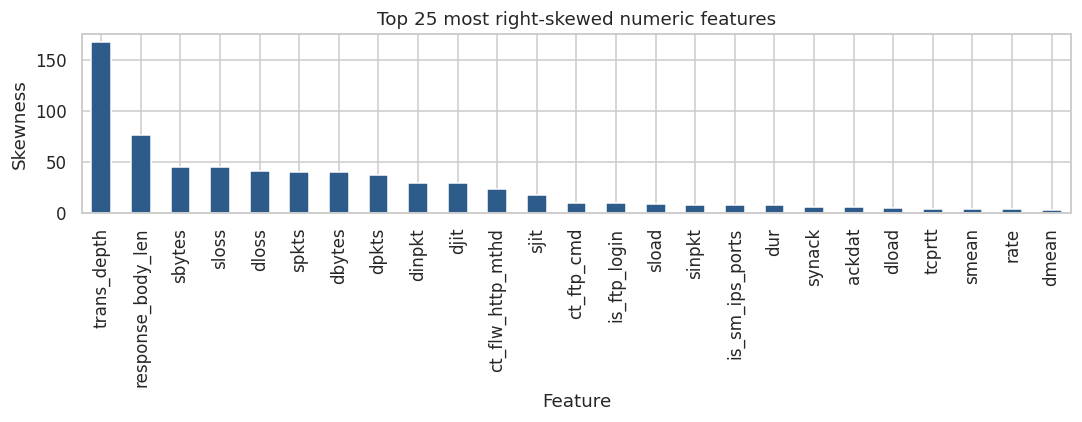

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
stat_table["skewness"].sort_values(ascending=False).head(25).plot.bar(ax=ax, color="#2D5B8A")
ax.set_title("Top 25 most right-skewed numeric features")
ax.set_ylabel("Skewness")
ax.set_xlabel("Feature")
plt.tight_layout()
plt.show()

**Reading.** Most traffic-volume features (bytes, packets, rates, durations) are extremely right-skewed with heavy tails — typical for network data where a few flows are enormous. This motivates log-scaling / robust scaling in Task 2 preprocessing, and means IQR "outliers" here are mostly *real traffic*, not errors — we keep them.

## C · Data quality

In [7]:
quality = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "missing_pct": (train.isna().mean() * 100).round(3),
    "n_unique": train.nunique(),
})

# Near-constant features: dominant value covers > 99% of rows
dominant_share = train.apply(lambda s: s.value_counts(normalize=True).iloc[0])
quality["dominant_value_pct"] = (dominant_share * 100).round(2)
near_constant = quality[(quality["dominant_value_pct"] > 99) & (~quality.index.isin(ID_COLS))]

print(f"total missing cells: {int(train.isna().sum().sum()):,}")
print(f"duplicate rows (excl. id): {int(train.drop(columns=ID_COLS).duplicated().sum()):,}")
print("\nnear-constant features (>99% one value):")
near_constant[["dtype", "n_unique", "dominant_value_pct"]]

total missing cells: 0
duplicate rows (excl. id): 67,601

near-constant features (>99% one value):


,dtype,n_unique,dominant_value_pct


In [8]:
# Highly-correlated numeric pairs (|r| > 0.95) -> redundancy candidates
corr = train[num_cols].corr(numeric_only=True)
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
high_pairs = (
    upper.stack()
    .rename("r")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)
high_pairs = high_pairs[high_pairs["r"].abs() > 0.95].sort_values("r", key=abs, ascending=False)
print(f"{len(high_pairs)} pairs with |r| > 0.95")
high_pairs.round(3)

12 pairs with |r| > 0.95


,feature_1,feature_2,r
726,is_ftp_login,ct_ftp_cmd,1.000
152,dbytes,dloss,0.997
117,sbytes,sloss,0.996
490,swin,dwin,0.990
684,ct_srv_src,ct_srv_dst,0.980
83,dpkts,dloss,0.979
724,ct_dst_src_ltm,ct_srv_dst,0.972
76,dpkts,dbytes,0.972
46,spkts,sloss,0.971
679,ct_srv_src,ct_dst_src_ltm,0.967


**Reading — effect on modeling.**
- *Missing values:* the partition CSVs are clean (0 missing) — no imputation needed.
- *Duplicates:* duplicated flows exist; they inflate whichever side of a random split they land on. Since we split by origin/time anyway (brief §6.2), we keep them but note the count.
- *Near-constant features:* carry almost no signal, candidates for dropping in Task 2 feature selection.
- *Highly-correlated pairs* (e.g. byte/packet counterparts, `sloss`/`sbytes`-type pairs): redundant; one of each pair can be dropped to shrink the model without losing information — also confirmed later by the heatmap (F).
- *`id` column:* pure row index — excluded everywhere, feeding it to a model would be leakage.

## D · Class balance

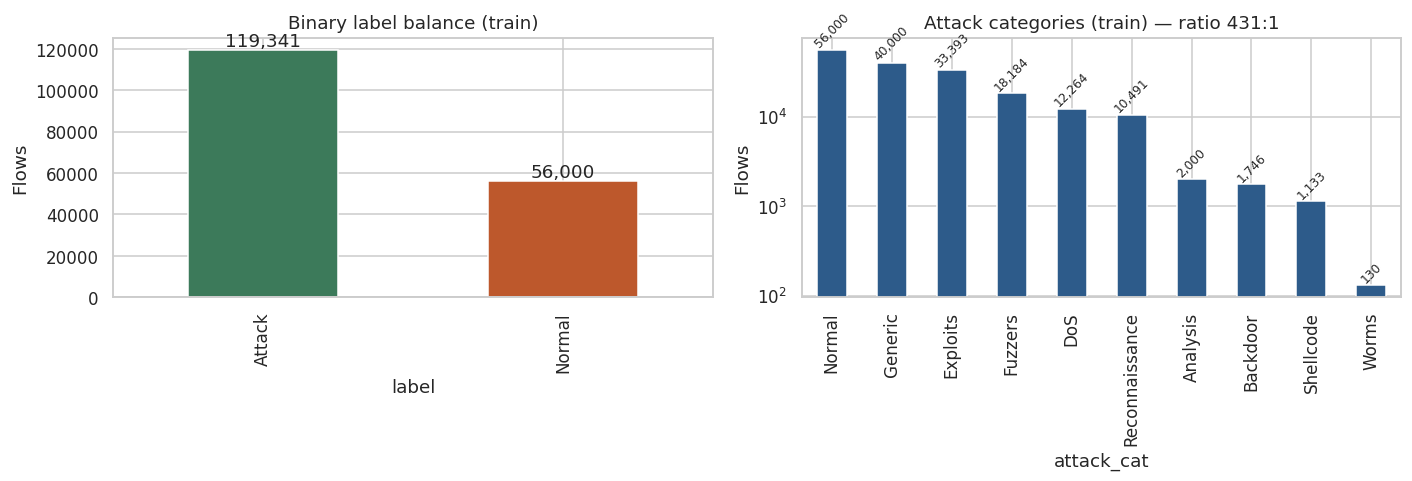

,count,share_pct
attack_cat,,
Normal,56000,31.94
Generic,40000,22.81
Exploits,33393,19.04
Fuzzers,18184,10.37
DoS,12264,6.99
Reconnaissance,10491,5.98
Analysis,2000,1.14
Backdoor,1746,1.00
Shellcode,1133,0.65


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

bin_counts = train[TARGET_BIN].value_counts().rename({0: "Normal", 1: "Attack"})
bin_counts.plot.bar(ax=axes[0], color=["#3C7A5A", "#BD582C"])
axes[0].set_title("Binary label balance (train)")
axes[0].set_ylabel("Flows")
for i, v in enumerate(bin_counts):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

multi_counts = train[TARGET_MULTI].value_counts()
multi_counts.plot.bar(ax=axes[1], color="#2D5B8A")
axes[1].set_title(f"Attack categories (train) — ratio {multi_counts.max() / multi_counts.min():,.0f}:1")
axes[1].set_ylabel("Flows")
axes[1].set_yscale("log")
for i, v in enumerate(multi_counts):
    axes[1].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8, rotation=45)

plt.tight_layout()
plt.show()

pd.DataFrame({
    "count": multi_counts,
    "share_pct": (multi_counts / len(train) * 100).round(2),
})

**Reading — effect on metrics.** The multiclass problem is severely imbalanced (note the log scale): Normal + Generic together dominate, while Worms / Shellcode / Backdoor / Analysis are tiny. A model predicting only the top classes would still show high *accuracy*. Consequences for the rest of the project:
1. Evaluate with **macro-F1 and per-class recall** (brief §6.2).
2. Task 2 must handle imbalance (class weights / focal loss / resampling on the training side only).
3. Rare-class performance is exactly where related work is weakest (CAGN-GAT paper targets it) — a candidate research gap.

## E · Feature distributions by class

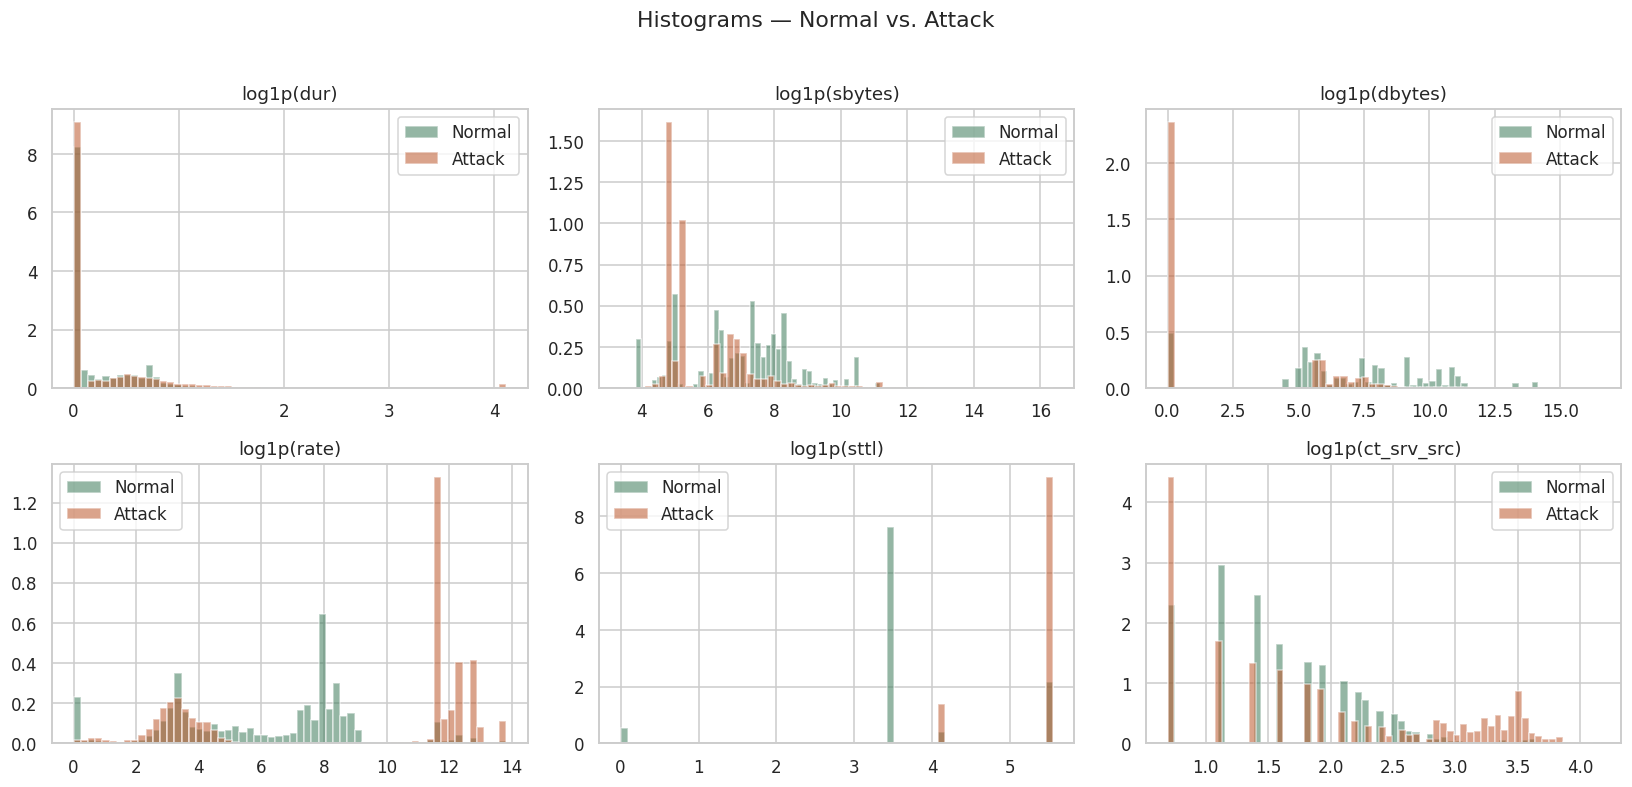

In [10]:
# Representative traffic features; log1p for readability (heavy tails, see B)
DIST_FEATURES = ["dur", "sbytes", "dbytes", "rate", "sttl", "ct_srv_src"]
DIST_FEATURES = [f for f in DIST_FEATURES if f in train.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, feat in zip(axes.ravel(), DIST_FEATURES):
    for lbl, name, color in [(0, "Normal", "#3C7A5A"), (1, "Attack", "#BD582C")]:
        vals = np.log1p(train.loc[train[TARGET_BIN] == lbl, feat])
        ax.hist(vals, bins=60, alpha=0.55, label=name, color=color, density=True)
    ax.set_title(f"log1p({feat})")
    ax.legend()
fig.suptitle("Histograms — Normal vs. Attack", y=1.02)
plt.tight_layout()
plt.show()

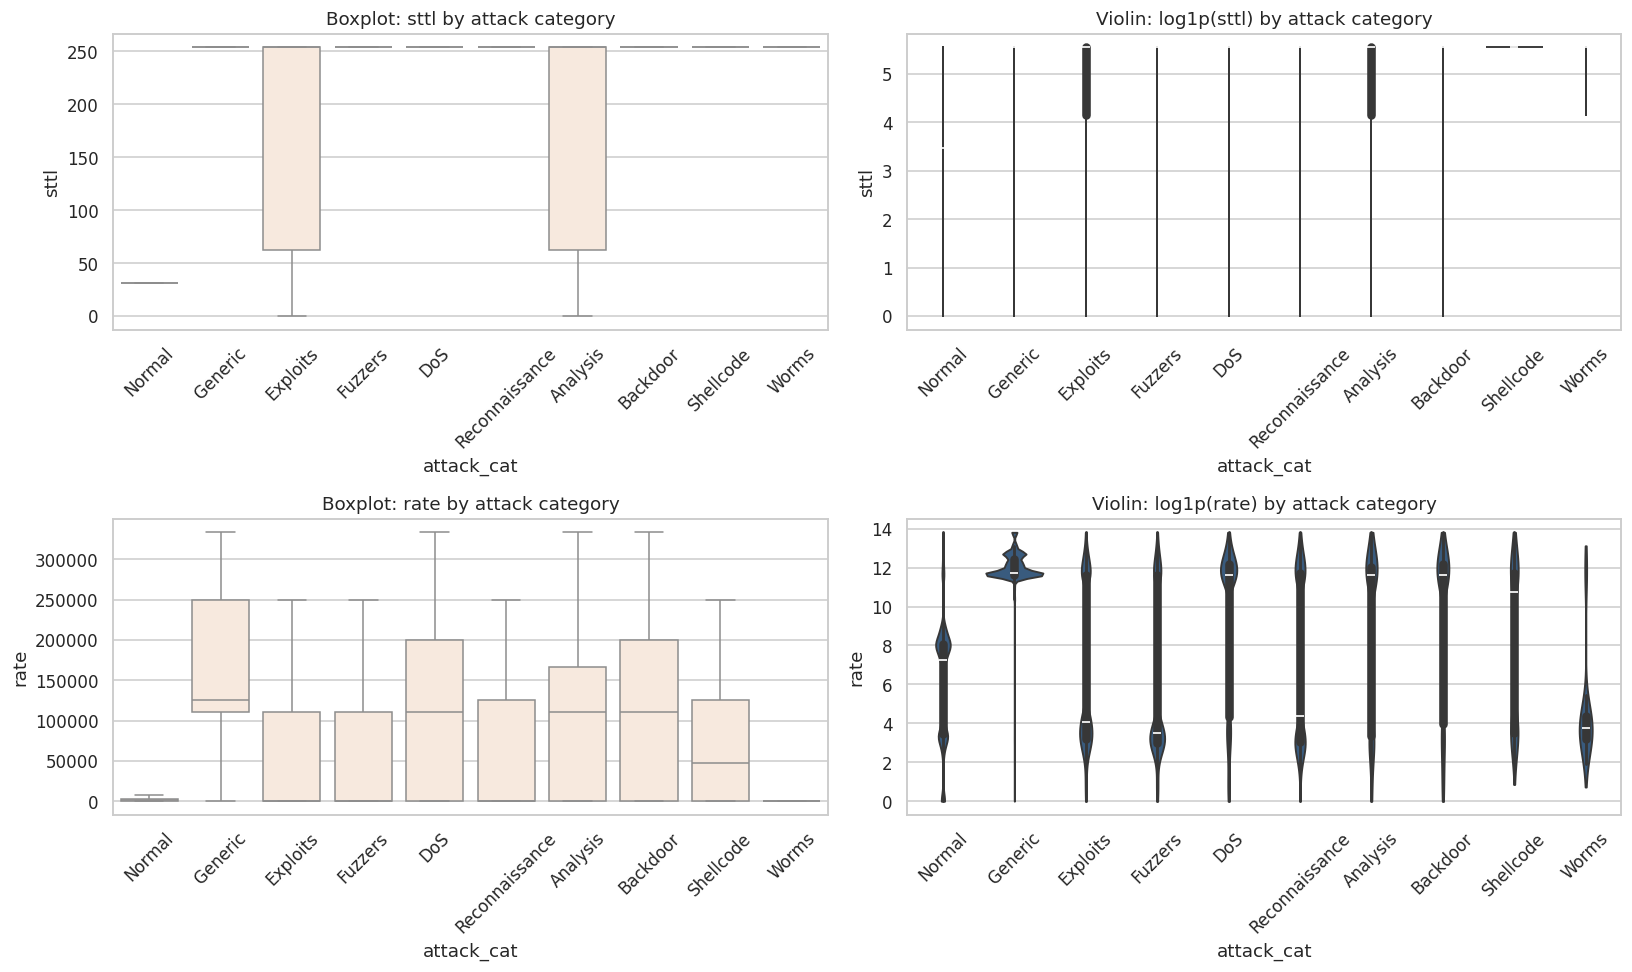

In [11]:
# Boxplots + violins across attack categories for two separating features
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

order = train[TARGET_MULTI].value_counts().index
for row, feat in enumerate(["sttl", "rate"]):
    if feat not in train.columns:
        continue
    sns.boxplot(data=train, x=TARGET_MULTI, y=feat, order=order, ax=axes[row][0],
                showfliers=False, color="#FBE8DA")
    axes[row][0].set_title(f"Boxplot: {feat} by attack category")
    axes[row][0].tick_params(axis="x", rotation=45)

    plot_df = train[[TARGET_MULTI, feat]].copy()
    plot_df[feat] = np.log1p(plot_df[feat])
    sns.violinplot(data=plot_df, x=TARGET_MULTI, y=feat, order=order, ax=axes[row][1],
                   cut=0, color="#2D5B8A")
    axes[row][1].set_title(f"Violin: log1p({feat}) by attack category")
    axes[row][1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Reading — do classes separate?** Yes, partially. `sttl` (source time-to-live) separates Normal from most attack traffic strikingly well — attack generators used distinct TTL defaults; this single feature will make even simple baselines strong. Byte/rate features separate Generic and Exploits from Normal, but Fuzzers and Analysis overlap Normal heavily, and rare classes (Worms, Shellcode) overlap other attacks — that overlap is where a GNN using *relational* structure could add value over row-wise models.

## F · Correlation heatmap

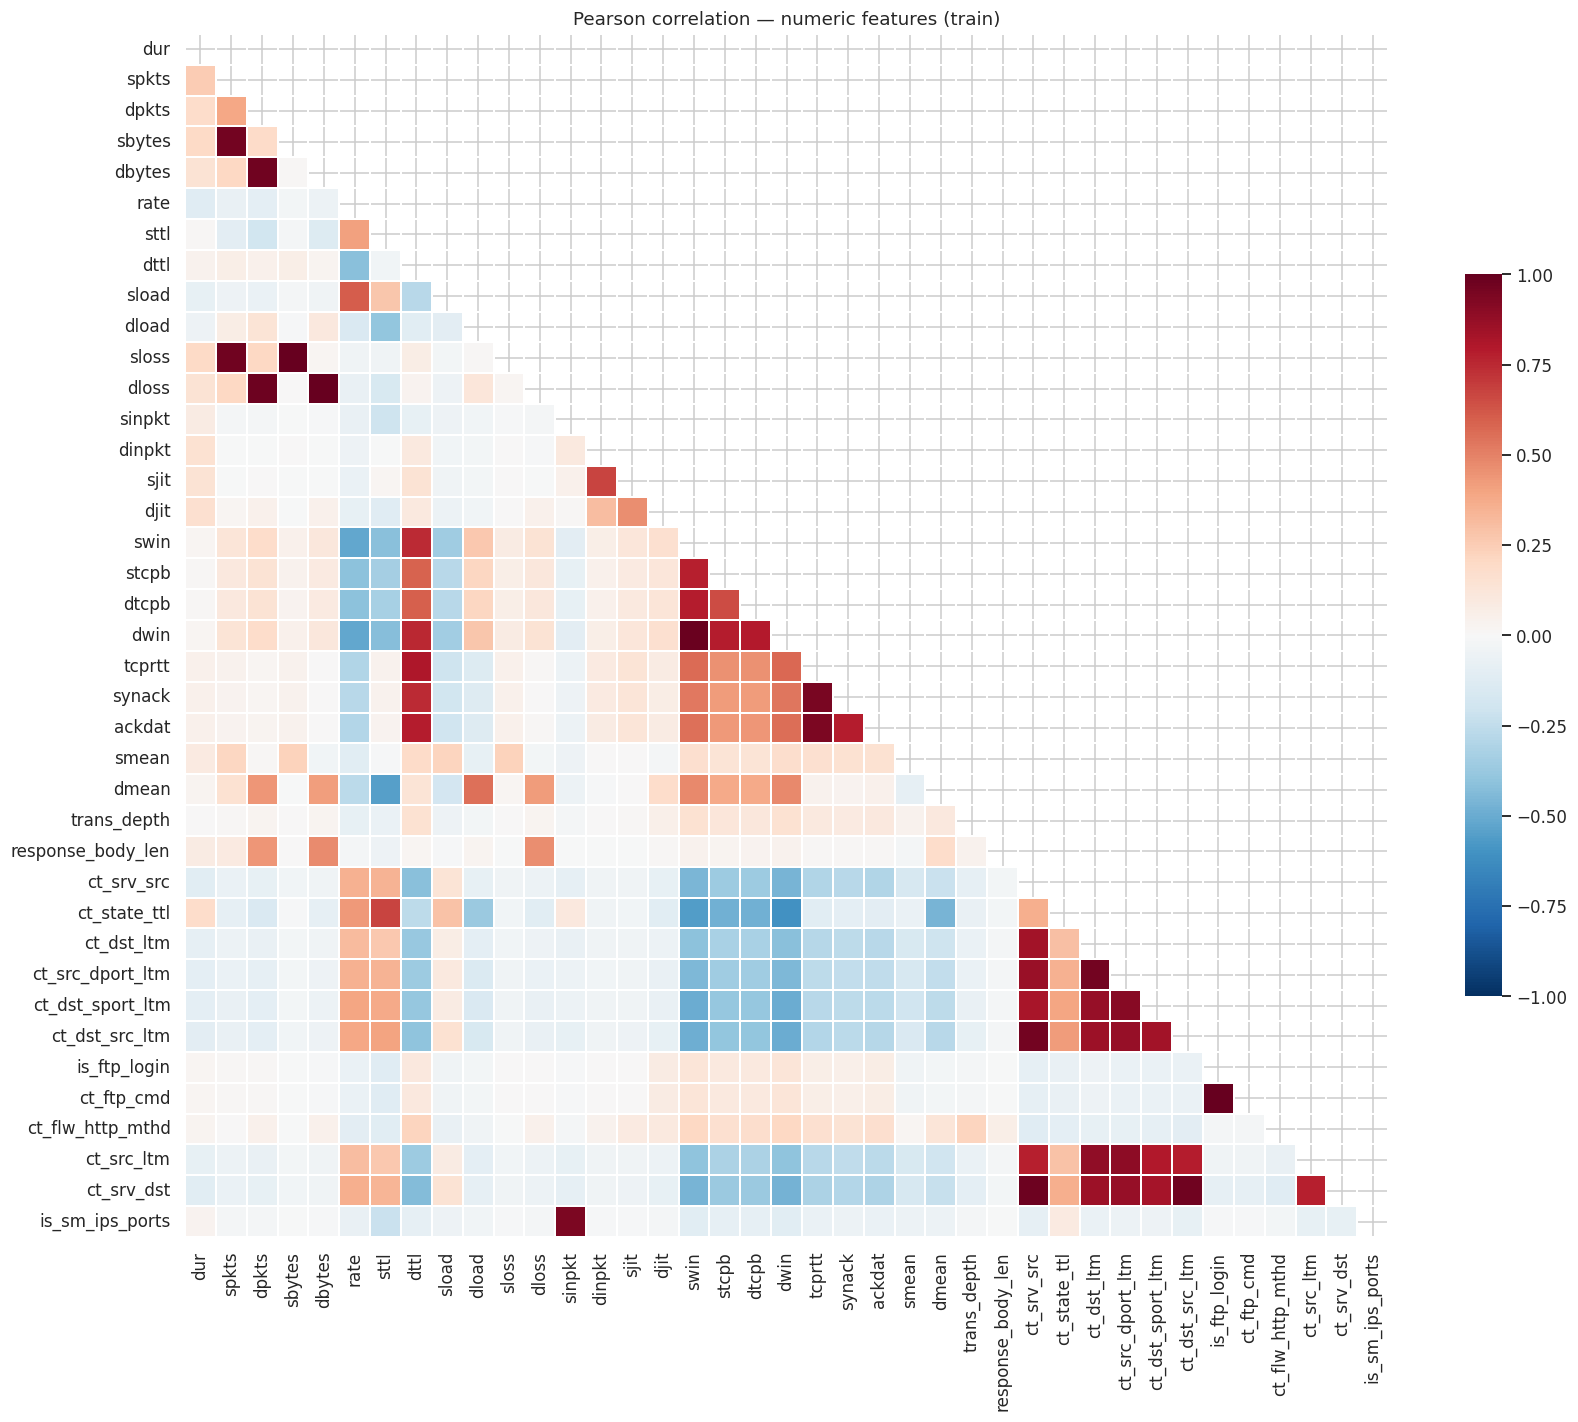

Redundant-feature candidates (drop one per pair in Task 2):


,feature_1,feature_2,r
726,is_ftp_login,ct_ftp_cmd,1.000
152,dbytes,dloss,0.997
117,sbytes,sloss,0.996
490,swin,dwin,0.990
684,ct_srv_src,ct_srv_dst,0.980
83,dpkts,dloss,0.979
724,ct_dst_src_ltm,ct_srv_dst,0.972
76,dpkts,dbytes,0.972
46,spkts,sloss,0.971
679,ct_srv_src,ct_dst_src_ltm,0.967


In [12]:
fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, cbar_kws={"shrink": 0.6}, ax=ax)
ax.set_title("Pearson correlation — numeric features (train)")
plt.tight_layout()
plt.show()

print("Redundant-feature candidates (drop one per pair in Task 2):")
high_pairs.round(3)

**Reading.** Clear red blocks: paired source/destination volume features (`sbytes`/`sloss`, `dbytes`/`dloss`, packet counts vs. byte counts) and the `ct_*` connection-count family correlate near 1. The list above is our redundant-feature shortlist — dropping one of each pair in Task 2 simplifies both the baselines and the GNN node features without losing information.

## G · 2D projections — PCA / t-SNE / UMAP

In [13]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Stratified sample keeps runtime sane and every class visible.
# Index-based sampling avoids the pandas 2.2 groupby.apply deprecation.
SAMPLE_PER_CLASS = 1200
sample_idx = np.concatenate([
    g.sample(min(len(g), SAMPLE_PER_CLASS), random_state=RANDOM_STATE).index.values
    for _, g in train.groupby(TARGET_MULTI, sort=False)
])
sample = train.loc[sample_idx]
X = StandardScaler().fit_transform(np.log1p(sample[num_cols].clip(lower=0)))
y = sample[TARGET_MULTI].values
print(f"projection sample: {X.shape[0]:,} rows")

pca = PCA(n_components=2, random_state=RANDOM_STATE)
emb_pca = pca.fit_transform(X)
print(f"PCA explained variance (2 comps): {pca.explained_variance_ratio_.sum():.1%}")

emb_tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=40,
                init="pca", learning_rate="auto").fit_transform(X)

try:
    from umap import UMAP
    emb_umap = UMAP(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
except ImportError:
    emb_umap = None
    print("umap-learn not installed -> skipping UMAP panel (%pip install umap-learn)")

projection sample: 10,863 rows
PCA explained variance (2 comps): 62.5%


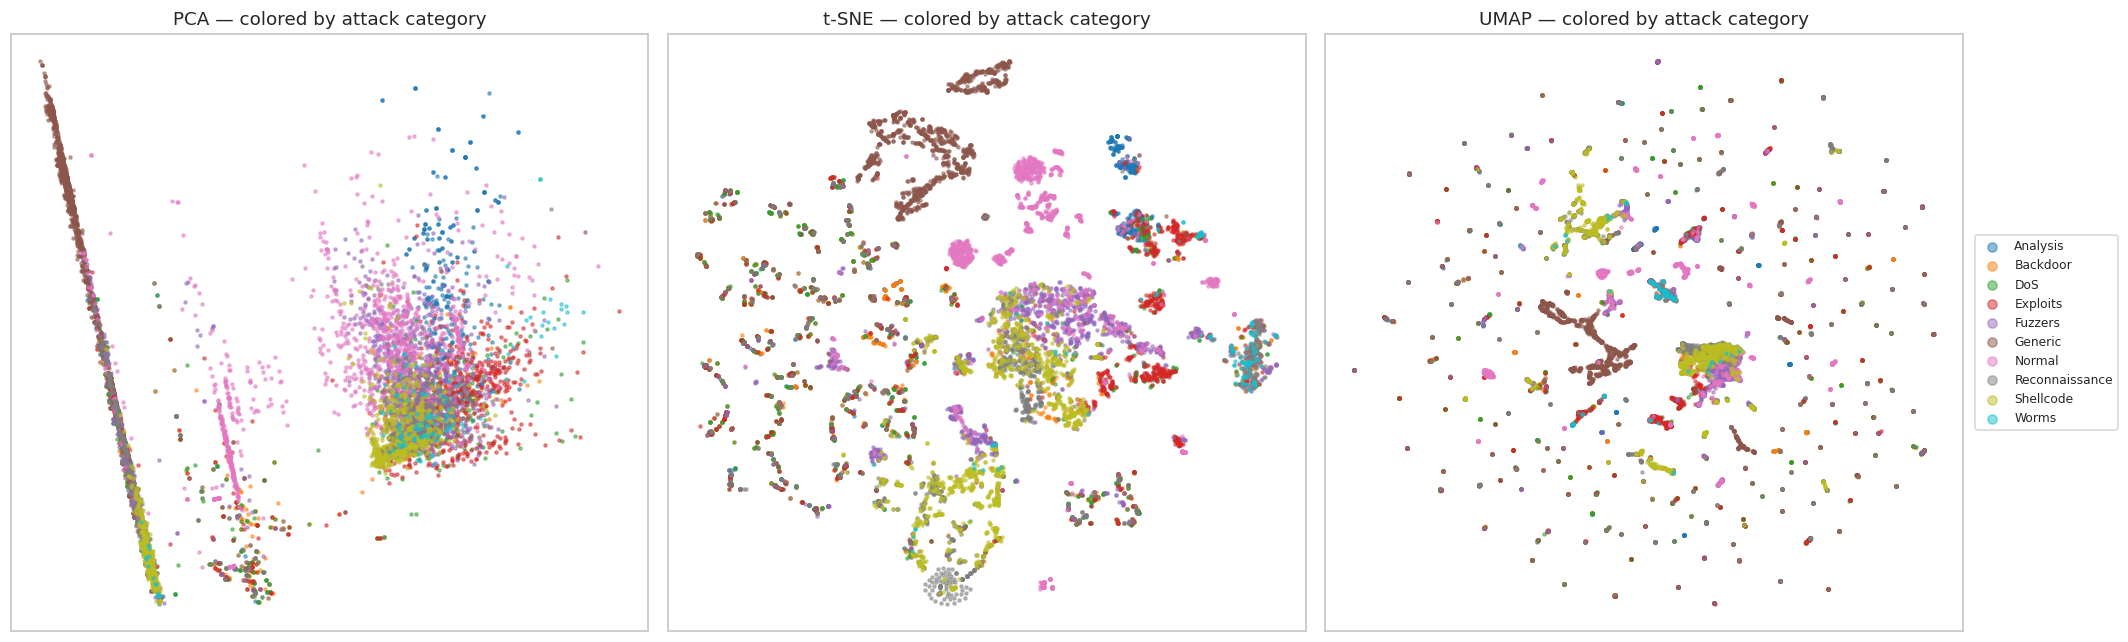

In [14]:
embeddings = [("PCA", emb_pca), ("t-SNE", emb_tsne)]
if emb_umap is not None:
    embeddings.append(("UMAP", emb_umap))

classes = sorted(np.unique(y))
palette = sns.color_palette("tab10", len(classes))

fig, axes = plt.subplots(1, len(embeddings), figsize=(6.5 * len(embeddings), 6))
axes = np.atleast_1d(axes)
for ax, (name, emb) in zip(axes, embeddings):
    for cls, color in zip(classes, palette):
        m = y == cls
        ax.scatter(emb[m, 0], emb[m, 1], s=4, alpha=0.5, color=color, label=cls)
    ax.set_title(f"{name} — colored by attack category")
    ax.set_xticks([]); ax.set_yticks([])
axes[-1].legend(markerscale=3, fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.show()

**Reading — do classes separate?** Normal and Generic form their own regions in t-SNE/UMAP — consistent with the strong `sttl`/rate signals from E. Exploits, Fuzzers, DoS and Reconnaissance smear into each other: row-wise features alone cannot cleanly split them. This is the core evidence for our research gap — a model using *relations between flows* (shared services, hosts, temporal proximity) has room to improve exactly where the point-cloud overlaps.

## H · Interactive plots (Plotly)

In [15]:
import plotly.express as px

fig = px.bar(
    multi_counts.reset_index().set_axis(["attack_cat", "count"], axis=1),
    x="attack_cat", y="count", log_y=True, text="count",
    title="Interactive: class distribution (train, log scale) — hover for exact counts",
    color="attack_cat",
)
fig.update_layout(showlegend=False, xaxis_title="Attack category", yaxis_title="Flows (log)")
fig.show()

In [16]:
tsne_df = pd.DataFrame(emb_tsne, columns=["x", "y"])
tsne_df["attack_cat"] = y
tsne_df["proto"] = sample["proto"].values if "proto" in sample.columns else "n/a"
tsne_df["service"] = sample["service"].values if "service" in sample.columns else "n/a"

fig = px.scatter(
    tsne_df, x="x", y="y", color="attack_cat",
    hover_data=["proto", "service"], opacity=0.6,
    title="Interactive t-SNE — hover shows protocol and service of each flow",
)
fig.update_traces(marker_size=4)
fig.update_layout(xaxis_visible=False, yaxis_visible=False)
fig.show()

In [17]:
feat = "sttl" if "sttl" in train.columns else num_cols[0]
fig = px.box(
    train.sample(min(len(train), 30000), random_state=RANDOM_STATE),
    x=TARGET_MULTI, y=feat, color=TARGET_BIN,
    title=f"Interactive: {feat} by attack category — toggle Normal/Attack in the legend",
)
fig.show()

**Reading.** The interactive views confirm the static ones and add drill-down: hovering the t-SNE clusters shows that several tight attack clusters share one `service` (e.g. dns/http heavy regions) — an early hint that *service* and *host-connection* relations are meaningful edges for the Task 2 graph construction.

## Conclusions & research gap

**What the data looks like**
1. Large, clean, feature-engineered flow dataset: no missing values, ~42 usable features, `id` excluded as ID-like.
2. Heavy-tailed, right-skewed traffic features → log/robust scaling needed in Task 2.
3. Severe class imbalance (four rare attack classes) → macro-F1 + per-class recall, imbalance handling mandatory.
4. A redundant-feature shortlist from near-perfect correlations → feature selection in Task 2.
5. `sttl` and rate features separate Normal vs. Attack well (strong baselines expected), but attack-vs-attack classes overlap in every projection.

**Research gap (feeds the Task 1 report)**
Related work (see `related_work/`) reaches ~97–99% *accuracy* with GNNs on UNSW-NB15, but: (a) reports accuracy on an imbalanced set rather than macro-F1; (b) rare-class (Worms/Shellcode/Backdoor) detection stays weak; (c) graph construction is manual and rarely justified or ablated; (d) explainability is mostly absent. **Our proposal:** a justified flow graph built *after* a leakage-free split, evaluated by macro-F1 with 5-fold CV + significance testing, with an ablation proving the graph helps and SHAP/LIME explanations — targeting exactly the overlapping attack classes where row-wise models saturate.

**Leakage guarantees carried into Task 2**
- Split by host/time before any graph is built.
- `id` (and any timestamp/IP columns if the raw version is used) never enter the model.
- Scalers, feature selection, and resampling fit on the training side only.